# Phase 3: Model Training & Evaluation

## 3.1 Environment Setup & Data Ingestion
To ensure absolute reproducibility, we compress the Phase 2 feature engineering pipeline (Train-Test Split, One-Hot Encoding, StandardScaler, and SMOTE) into a single initialization block.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Load Data
df = pd.read_csv('../data/bank_churn.csv').drop(['customer_id'], axis=1)
X = df.drop(['churn'], axis=1)
y = df['churn']

# 2. Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Encode
gender_map = {'Male': 1, 'Female': 0}
X_train['gender'] = X_train['gender'].map(gender_map)
X_test['gender'] = X_test['gender'].map(gender_map)

encoder = OneHotEncoder(sparse_output=False, drop='first')
ohe_cols = encoder.fit(X_train[['country']]).get_feature_names_out(['country'])
X_train = pd.concat([X_train.drop('country', axis=1), pd.DataFrame(encoder.transform(X_train[['country']]), columns=ohe_cols, index=X_train.index)], axis=1)
X_test = pd.concat([X_test.drop('country', axis=1), pd.DataFrame(encoder.transform(X_test[['country']]), columns=ohe_cols, index=X_test.index)], axis=1)

# 4. Scale
cols_to_scale = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 5. Balance (SMOTE on Train ONLY)
X_train_balanced, y_train_balanced = SMOTE(random_state=42).fit_resample(X_train, y_train)

print(f"Pipeline Complete. Ready for Training.")
print(f"Training Matrix: {X_train_balanced.shape} | Testing Matrix: {X_test.shape}")

Pipeline Complete. Ready for Training.
Training Matrix: (12740, 11) | Testing Matrix: (2000, 11)


## 3.2 The Baseline Model: Logistic Regression

### Objective
Establish a baseline performance metric using a highly interpretable, linear statistical model. Advanced ensemble models (like Random Forest) must significantly outperform this baseline to justify their computational expense.

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1593
           1       0.39      0.68      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



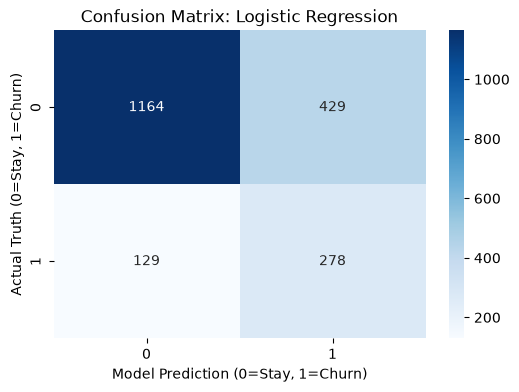

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Model
# max_iter is increased to ensure the algorithm has enough time to find the mathematical bottom of the curve
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# 2. Train the Model (The "Learning" Phase)
# We feed it the balanced textbook so it learns fairly
log_reg.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions (The "Exam")
# We test it on the untouched, unbalanced 20% real-world data
y_pred_log = log_reg.predict(X_test)

# 4. Evaluate the Results
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Actual Truth (0=Stay, 1=Churn)')
plt.xlabel('Model Prediction (0=Stay, 1=Churn)')
plt.show()

## 3.3 Advanced Ensemble Modeling: Random Forest

### Objective
Deploy a non-linear, tree-based ensemble algorithm to capture complex feature interactions that our baseline Logistic Regression model failed to detect, aiming to improve Precision without sacrificing Recall.

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.62      0.59      0.61       407

    accuracy                           0.84      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.84      0.84      2000



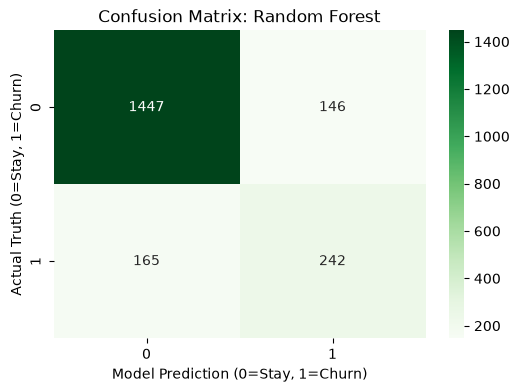

In [3]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Model
# n_estimators=100 means we are building a forest of 100 individual decision trees
# random_state ensures we get the exact same results every time we run it
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model on the Balanced Data
rf_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the Test Data
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate the Results
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Actual Truth (0=Stay, 1=Churn)')
plt.xlabel('Model Prediction (0=Stay, 1=Churn)')
plt.show()

## 3.4 Extreme Gradient Boosting (XGBoost)

### Objective
Deploy a gradient boosting framework to sequentially correct residual errors from previous trees, aiming to achieve the optimal balance between Precision and Recall.

d:\mlproject_01\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:10:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.66      0.56      0.61       407

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.84      0.85      0.85      2000



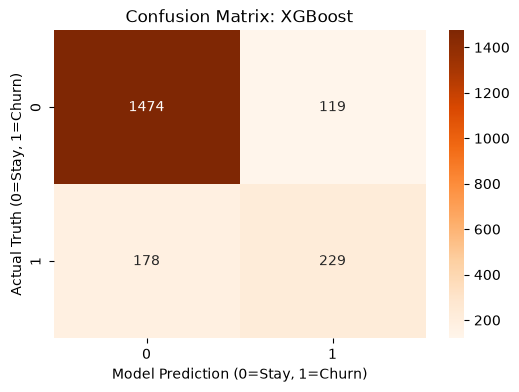

In [4]:
from xgboost import XGBClassifier

# 1. Initialize the Model
# use_label_encoder=False and eval_metric suppress unnecessary terminal warnings
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Train the Model 
xgb_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate the Results
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix: XGBoost')
plt.ylabel('Actual Truth (0=Stay, 1=Churn)')
plt.xlabel('Model Prediction (0=Stay, 1=Churn)')
plt.show()

Starting Grid Search... This might take a minute as it tests multiple combinations!
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Winning Parameters Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

--- OPTIMIZED XGBoost Classification Report (Threshold = 0.40) ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1593
           1       0.59      0.63      0.61       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.84      0.84      0.84      2000



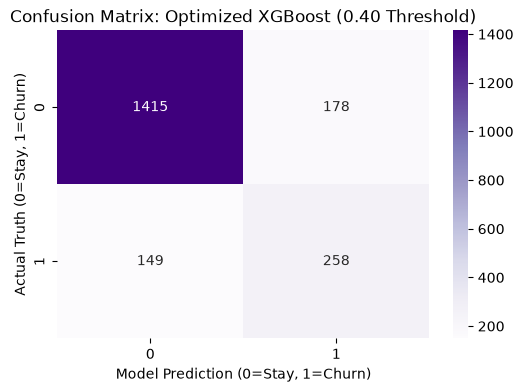

In [5]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting Grid Search... This might take a minute as it tests multiple combinations!")

# 1. Define the Dials to Tune (Hyperparameter Grid)
# We are testing 12 different combinations of trees and learning speeds
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

# 2. Initialize the Base Model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Run the Grid Search
# cv=3 means it cross-validates 3 times to ensure the results aren't a fluke
# scoring='f1' tells the search to specifically look for the best F1-Score
grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, scoring='f1', cv=3, verbose=1)
grid_search.fit(X_train_balanced, y_train_balanced)

# 4. Extract the Ultimate Champion Model
best_xgb = grid_search.best_estimator_
print(f"\nWinning Parameters Found: {grid_search.best_params_}\n")

# ==========================================
# THE SECRET WEAPON: THRESHOLD MOVING
# ==========================================

# Instead of asking for a hard 1 or 0, we ask for the raw percentage probability
# [:, 1] gets the probability specifically for Class 1 (Churn)
y_pred_probs = best_xgb.predict_proba(X_test)[:, 1]

# We lower the alarm threshold from the default 50% down to 40%
custom_threshold = 0.40
y_pred_optimized = (y_pred_probs >= custom_threshold).astype(int)

# ==========================================
# EVALUATE THE OPTIMIZED MODEL
# ==========================================

print("--- OPTIMIZED XGBoost Classification Report (Threshold = 0.40) ---")
print(classification_report(y_test, y_pred_optimized))

# Visualize the new Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Optimized XGBoost (0.40 Threshold)')
plt.ylabel('Actual Truth (0=Stay, 1=Churn)')
plt.xlabel('Model Prediction (0=Stay, 1=Churn)')
plt.show()

## 3.7 Model Serialization (Exporting Artifacts)

### Objective
Save the optimized XGBoost model and the data preprocessing objects (Scaler, Encoder) to disk as binary `.pkl` files. This allows the Flask Web Application to load the model and apply the exact same mathematical transformations to new, live user input.

In [6]:
import joblib
import os

# 1. Create the artifacts folder if it doesn't exist
os.makedirs('../artifacts', exist_ok=True)

# 2. Save the Champion Model
joblib.dump(best_xgb, '../artifacts/xgboost_model.pkl')

# 3. Save the Translators
joblib.dump(scaler, '../artifacts/scaler.pkl')
joblib.dump(encoder, '../artifacts/encoder.pkl')

print("✅ SUCCESS: Model and Translators saved to the artifacts folder!")

✅ SUCCESS: Model and Translators saved to the artifacts folder!
